# L2 label frontier and sensitivity (EWE)

**Goal**: let the data speak about how robust the L2 label is
(Extreme Wildfire Event = FLI >= 10,000 kW/m, Tedim 2018) on the 2016-2017 subset.

The real run yielded **only 5 EWE** out of 12,381 events. With N so small, a one-event
difference shifts prevalence by ~20%. This notebook examines:

1. The FLI distribution and where the threshold falls.
2. The 5 EWE and the events on the frontier (near-EWE, blocked by the area guard).
3. Sensitivity of N(EWE) to: FLI threshold, radiant fraction eta_r, and area guard.
4. L2 (satellite FLI) vs L1b (hectares P99/Pareto) comparison.
5. Reading: is 2016-2017 enough, or should the time window be widened before modeling?

> Note: the 36 ERA5 columns are 100% null in this subset, hence no climate crosses.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "eda" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.modis import (FLI_EWE_THRESHOLD_KW_M, RADIANT_FRACTION,
                       MODIS_PIXEL_LENGTH_M, MIN_AREA_HA_FOR_L2, frp_to_fli)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.1f}")

AREA = "superficie_quemada_total_ha"
df = pd.read_parquet(ROOT / "data" / "processed" / "conaf_enriched_latest.parquet")
det = df[df["modis_frp_max_mw"].notna()].copy()   # only events with a MODIS detection

print(f"EWE threshold      : {FLI_EWE_THRESHOLD_KW_M:,.0f} kW/m  (eta_r={RADIANT_FRACTION}, L_px={MODIS_PIXEL_LENGTH_M:.0f} m)")
print(f"Area guard         : {MIN_AREA_HA_FOR_L2:.0f} ha")
print(f"Total events       : {len(df):,}")
print(f"With MODIS detection: {len(det):,} ({100*len(det)/len(df):.1f}%)")
print(f"EWE (label_l2 = 1) : {int(df['label_l2'].sum())}")

EWE threshold      : 10,000 kW/m  (eta_r=0.17, L_px=1000 m)
Area guard         : 50 ha
Total events       : 12,381
With MODIS detection: 1,325 (10.7%)
EWE (label_l2 = 1) : 5


## 1. FLI distribution

Only events with a MODIS detection have an estimated FLI. Where does the mass of the
distribution sit relative to the EWE threshold of 10,000 kW/m?

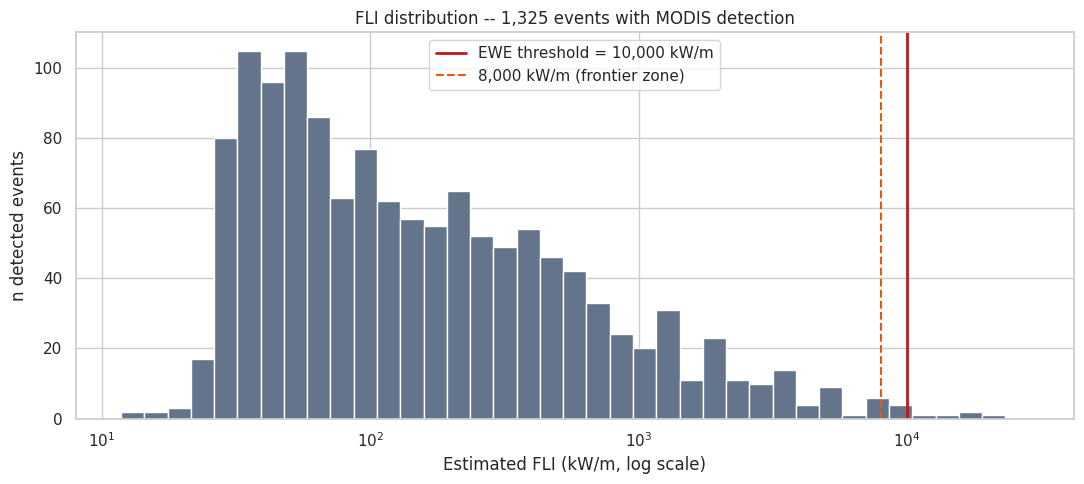

Count per FLI band:
       0 -    2,000 kW/m :  1256
   2,000 -    5,000 kW/m :    48
   5,000 -    8,000 kW/m :    11
   8,000 -   10,000 kW/m :     3
  10,000 -      inf kW/m :     7

Equivalence: FLI 10,000 kW/m  <=>  FRP ~ 1,700 MW


In [2]:
fli = det["fli_estimado_kw_m"]
bins = np.logspace(np.log10(fli.min()), np.log10(fli.max()), 40)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(fli, bins=bins, color="#64748b", edgecolor="white")
ax.set_xscale("log")
ax.axvline(FLI_EWE_THRESHOLD_KW_M, color="#b91c1c", lw=2,
           label=f"EWE threshold = {FLI_EWE_THRESHOLD_KW_M:,.0f} kW/m")
ax.axvline(8000, color="#ea580c", lw=1.5, ls="--", label="8,000 kW/m (frontier zone)")
ax.set_xlabel("Estimated FLI (kW/m, log scale)")
ax.set_ylabel("n detected events")
ax.set_title(f"FLI distribution -- {len(det):,} events with MODIS detection")
ax.legend()
plt.tight_layout(); plt.show()

print("Count per FLI band:")
for lo, hi in [(0,2000),(2000,5000),(5000,8000),(8000,10000),(10000,np.inf)]:
    n = int(((fli >= lo) & (fli < hi)).sum())
    hi_txt = "inf" if hi == np.inf else f"{hi:,.0f}"
    print(f"  {lo:>6,.0f} - {hi_txt:>8} kW/m : {n:>5}")

frp_threshold = FLI_EWE_THRESHOLD_KW_M * RADIANT_FRACTION * MODIS_PIXEL_LENGTH_M / 1000
print(f"\nEquivalence: FLI {FLI_EWE_THRESHOLD_KW_M:,.0f} kW/m  <=>  FRP ~ {frp_threshold:,.0f} MW")

## 2. The frontier: the 5 EWE and their neighbors

Three groups: (a) confirmed EWE, (b) near-EWE just below the threshold with valid area,
(c) events that cross the FLI threshold but are blocked by the area guard (false positives
from spatial attribution of a neighboring megafire's FRP).

In [3]:
area = det[AREA]
show = ["region", "comuna", "fecha_hora_inicio", AREA, "modis_frp_max_mw", "fli_estimado_kw_m"]

ewe     = det[(fli >= FLI_EWE_THRESHOLD_KW_M) & (area >= MIN_AREA_HA_FOR_L2)].sort_values("fli_estimado_kw_m", ascending=False)
near    = det[(fli >= 7000) & (fli < FLI_EWE_THRESHOLD_KW_M) & (area >= MIN_AREA_HA_FOR_L2)].sort_values("fli_estimado_kw_m", ascending=False)
blocked = det[(fli >= FLI_EWE_THRESHOLD_KW_M) & (area < MIN_AREA_HA_FOR_L2)].sort_values("fli_estimado_kw_m", ascending=False)

print(f"(a) Confirmed EWE: {len(ewe)}")
display(ewe[show])
print(f"(b) near-EWE (7,000-10,000 kW/m, area >= 50 ha): {len(near)}  -- the closest sits at {100*(1-near['fli_estimado_kw_m'].max()/FLI_EWE_THRESHOLD_KW_M):.1f}% below the threshold")
display(near[show])
print(f"(c) blocked by the area guard (FLI >= 10,000, area < 50 ha): {len(blocked)}")
display(blocked[show])

(a) Confirmed EWE: 5


,region,comuna,fecha_hora_inicio,superficie_quemada_total_ha,modis_frp_max_mw,fli_estimado_kw_m
9007,Biobío,Quirihue,2017-01-25 17:34:00,"10,829.8","4,819.3","28,348.8"
9574,Araucanía,Lumaco,2017-01-22 07:00:00,"1,848.7","3,798.6","22,344.7"
7235,Maule,Cauquenes,2017-01-20 22:01:00,"159,812.6","2,906.7","17,098.2"
6681,O'Higgins,Pumanque,2017-01-17 16:35:00,"46,490.0","1,825.0","10,735.3"
6594,O'Higgins,Paredones,2016-12-13 15:42:00,"1,298.0","1,746.9","10,275.9"


(b) near-EWE (7,000-10,000 kW/m, area >= 50 ha): 5  -- the closest sits at 4.0% below the threshold


,region,comuna,fecha_hora_inicio,superficie_quemada_total_ha,modis_frp_max_mw,fli_estimado_kw_m
4332,Araucanía,Perquenco,2016-02-10 15:20:00,"1,100.0","1,631.8","9,598.8"
8962,Biobío,Penco,2017-01-25 15:07:00,340.7,"1,258.1","7,400.6"
8976,Biobío,Concepción,2017-01-25 18:14:00,"2,240.4","1,258.1","7,400.6"
6545,O'Higgins,Litueche,2016-11-17 12:53:00,"3,438.0","1,233.5","7,255.9"
9011,Biobío,Portezuelo,2017-01-28 10:00:00,"4,353.2","1,199.5","7,055.9"


(c) blocked by the area guard (FLI >= 10,000, area < 50 ha): 2


,region,comuna,fecha_hora_inicio,superficie_quemada_total_ha,modis_frp_max_mw,fli_estimado_kw_m
8994,Biobío,Tomé,2017-01-26 15:46:00,0.0,"2,940.8","17,298.8"
8379,Biobío,Hualqui,2017-01-26 09:44:00,0.2,"2,230.7","13,121.8"


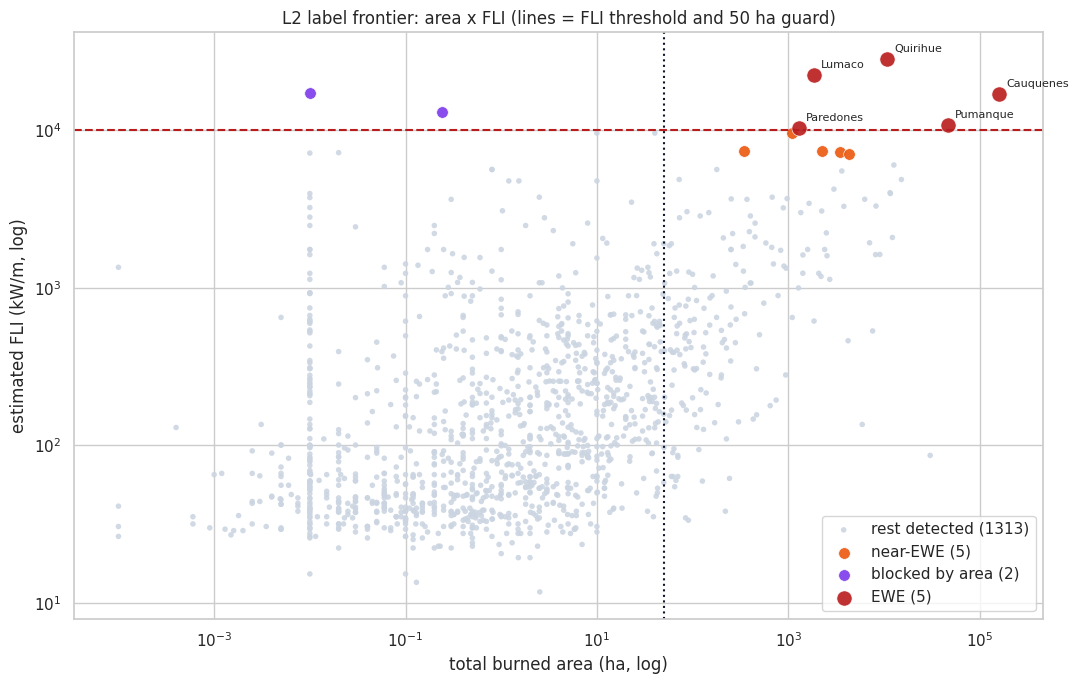

In [4]:
d = det[det[AREA] > 0].copy()
d["category"] = "rest detected"
d.loc[(d["fli_estimado_kw_m"] >= 7000) & (d["fli_estimado_kw_m"] < FLI_EWE_THRESHOLD_KW_M) & (d[AREA] >= MIN_AREA_HA_FOR_L2), "category"] = "near-EWE"
d.loc[(d["fli_estimado_kw_m"] >= FLI_EWE_THRESHOLD_KW_M) & (d[AREA] < MIN_AREA_HA_FOR_L2), "category"] = "blocked by area"
d.loc[(d["fli_estimado_kw_m"] >= FLI_EWE_THRESHOLD_KW_M) & (d[AREA] >= MIN_AREA_HA_FOR_L2), "category"] = "EWE"

palette = {"rest detected": "#cbd5e1", "near-EWE": "#ea580c", "blocked by area": "#7c3aed", "EWE": "#b91c1c"}
sizes   = {"rest detected": 16, "near-EWE": 70, "blocked by area": 70, "EWE": 120}

fig, ax = plt.subplots(figsize=(11, 7))
for cat, color in palette.items():
    sub = d[d["category"] == cat]
    ax.scatter(sub[AREA], sub["fli_estimado_kw_m"], s=sizes[cat], c=color,
               label=f"{cat} ({len(sub)})", alpha=0.9,
               edgecolor="none" if cat == "rest detected" else "white",
               linewidth=0.5, zorder=3 if cat == "EWE" else 2)
ax.set_xscale("log"); ax.set_yscale("log")
ax.axhline(FLI_EWE_THRESHOLD_KW_M, color="#b91c1c", ls="--", lw=1.5)
ax.axvline(MIN_AREA_HA_FOR_L2, color="#0f172a", ls=":", lw=1.5)
ax.set_xlabel("total burned area (ha, log)")
ax.set_ylabel("estimated FLI (kW/m, log)")
ax.set_title("L2 label frontier: area x FLI (lines = FLI threshold and 50 ha guard)")
for _, r in d[d["category"] == "EWE"].iterrows():
    ax.annotate(r["comuna"], (r[AREA], r["fli_estimado_kw_m"]),
                fontsize=8, xytext=(5, 5), textcoords="offset points")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 3. Sensitivity to the FLI threshold

How many EWE would there be if we moved the threshold? The curve shows how fragile N(EWE)
is around 10,000 kW/m (with the area guard fixed at 50 ha).

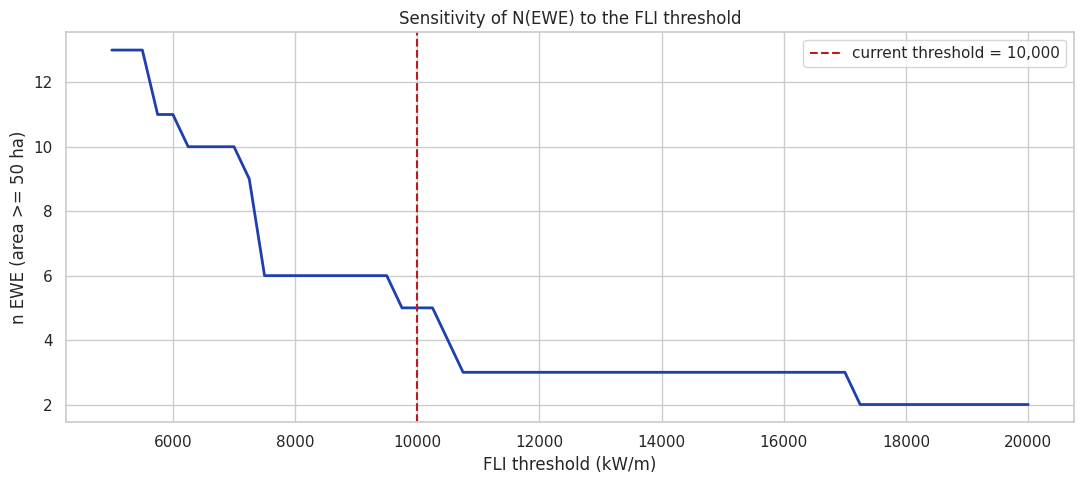

,threshold_kw_m,n_EWE
0,8000,6
1,9000,6
2,10000,5
3,11000,3
4,12000,3


In [5]:
area_ok = det[AREA] >= MIN_AREA_HA_FOR_L2
ths = np.arange(5000, 20001, 250)
n_curve = [int(((det["fli_estimado_kw_m"] >= t) & area_ok).sum()) for t in ths]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ths, n_curve, color="#1e40af", lw=2)
ax.axvline(FLI_EWE_THRESHOLD_KW_M, color="#b91c1c", ls="--", label="current threshold = 10,000")
ax.set_xlabel("FLI threshold (kW/m)")
ax.set_ylabel("n EWE (area >= 50 ha)")
ax.set_title("Sensitivity of N(EWE) to the FLI threshold")
ax.legend()
plt.tight_layout(); plt.show()

table = pd.DataFrame({"threshold_kw_m": [8000, 9000, 10000, 11000, 12000]})
table["n_EWE"] = [int(((det["fli_estimado_kw_m"] >= t) & area_ok).sum()) for t in table["threshold_kw_m"]]
display(table)

## 4. Sensitivity to the radiant fraction eta_r

Wooster 2003 reports eta_r in the 0.13-0.20 range; we use 0.17 by default. Since
FLI ~ 1/eta_r, a lower eta_r raises the estimated FLI and can bring in new EWE.

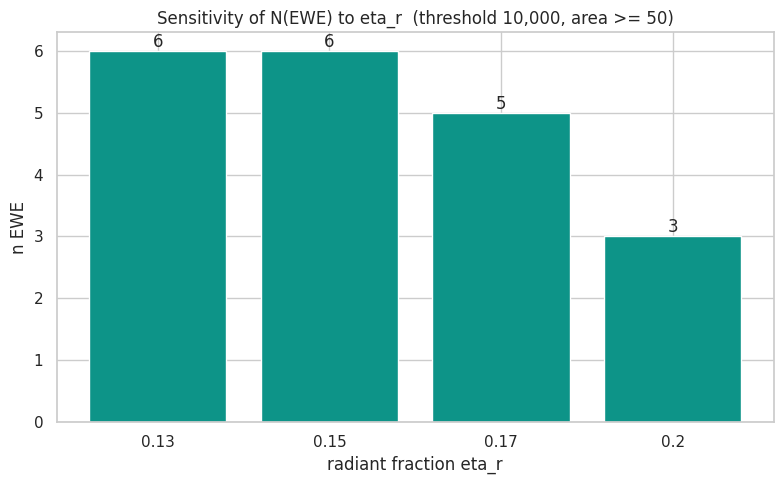

,eta_r,n_EWE
0,0.1,6
1,0.1,6
2,0.2,5
3,0.2,3


Events that would become EWE if eta_r = 0.16: 1


,region,comuna,superficie_quemada_total_ha,modis_frp_max_mw,fli_estimado_kw_m
4332,Araucanía,Perquenco,"1,100.0","1,631.8","9,598.8"


In [6]:
frp = det["modis_frp_max_mw"]
etas = [0.13, 0.15, 0.17, 0.20]
sens_eta = pd.DataFrame({"eta_r": etas})
sens_eta["n_EWE"] = [
    int(((frp.apply(lambda f: frp_to_fli(f, MODIS_PIXEL_LENGTH_M, e)) >= FLI_EWE_THRESHOLD_KW_M) & area_ok).sum())
    for e in etas
]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sens_eta["eta_r"].astype(str), sens_eta["n_EWE"], color="#0d9488")
ax.bar_label(bars)
ax.set_xlabel("radiant fraction eta_r")
ax.set_ylabel("n EWE")
ax.set_title("Sensitivity of N(EWE) to eta_r  (threshold 10,000, area >= 50)")
plt.tight_layout(); plt.show()
display(sens_eta)

fli_016 = frp.apply(lambda f: frp_to_fli(f, MODIS_PIXEL_LENGTH_M, 0.16))
newcomers = det[(fli_016 >= FLI_EWE_THRESHOLD_KW_M) & area_ok & (det["fli_estimado_kw_m"] < FLI_EWE_THRESHOLD_KW_M)]
print(f"Events that would become EWE if eta_r = 0.16: {len(newcomers)}")
display(newcomers[["region", "comuna", AREA, "modis_frp_max_mw", "fli_estimado_kw_m"]])

## 5. Sensitivity to the area guard

The guard (area >= 50 ha) discards false positives where the 5 km matching captured a
neighboring megafire's FRP. How much does N(EWE) change depending on where we set it?

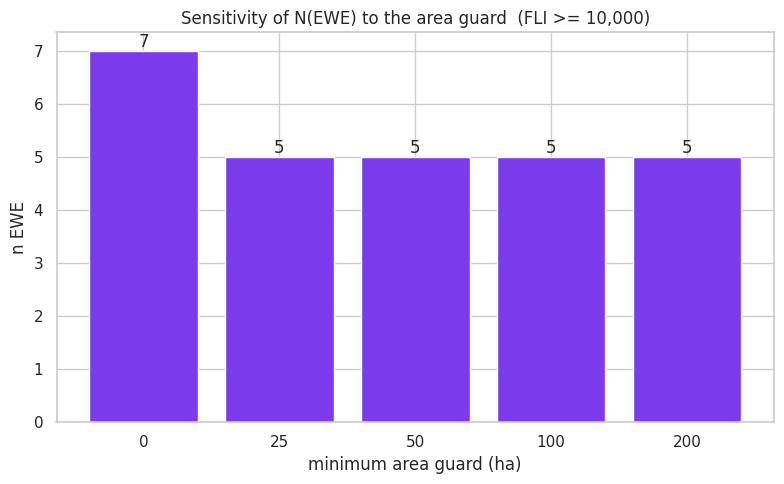

,A_min_ha,n_EWE
0,0,7
1,25,5
2,50,5
3,100,5
4,200,5


In [7]:
fli_ok = det["fli_estimado_kw_m"] >= FLI_EWE_THRESHOLD_KW_M
amins = [0, 25, 50, 100, 200]
sens_area = pd.DataFrame({"A_min_ha": amins})
sens_area["n_EWE"] = [int((fli_ok & (det[AREA] >= a)).sum()) for a in amins]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(sens_area["A_min_ha"].astype(str), sens_area["n_EWE"], color="#7c3aed")
ax.bar_label(bars)
ax.set_xlabel("minimum area guard (ha)")
ax.set_ylabel("n EWE")
ax.set_title("Sensitivity of N(EWE) to the area guard  (FLI >= 10,000)")
plt.tight_layout(); plt.show()
display(sens_area)

## 6. L2 (satellite FLI) vs L1b (hectares) comparison

L2 is the target of interest (Tedim 2018); L1b is the area proxy (per-region threshold =
max(P99, Pareto-80) if n>=50, via `scripts/megafire_thresholds.py`). The disagreements are
the interesting part: an event can be EWE by intensity but not by size, and vice versa.

In [8]:
from scripts.megafire_thresholds import build_table

thr_table = build_table(df)
thr_map = thr_table[thr_table["region"] != "GLOBAL"].set_index("region")["recomendado_ha"].to_dict()
global_thr = float(thr_table.loc[thr_table["region"] == "GLOBAL", "recomendado_ha"].iloc[0])

df_cmp = df.copy()
df_cmp["umbral_l1b_region"] = df_cmp["region"].map(thr_map).fillna(global_thr)
df_cmp["label_l1b"] = (df_cmp[AREA] >= df_cmp["umbral_l1b_region"]).astype(int)

ct = pd.crosstab(df_cmp["label_l1b"], df_cmp["label_l2"], margins=True, margins_name="Total")
print("Crosstab  L1b (rows) x L2 (columns):")
display(ct)

only_l2 = df_cmp[(df_cmp["label_l2"] == 1) & (df_cmp["label_l1b"] == 0)]
print(f"\nL2-only (EWE by intensity, NOT a megafire by hectares): {len(only_l2)}")
display(only_l2[["region", "comuna", AREA, "umbral_l1b_region", "fli_estimado_kw_m"]])

only_l1b = df_cmp[(df_cmp["label_l1b"] == 1) & (df_cmp["label_l2"] == 0)]
print(f"\nL1b-only (megafire by hectares, NOT EWE by intensity): {len(only_l1b)} -- top 10 by area")
display(only_l1b.sort_values(AREA, ascending=False).head(10)[["region", "comuna", AREA, "modis_n_matches", "fli_estimado_kw_m"]])

Crosstab  L1b (rows) x L2 (columns):


label_l2,0,1,Total
label_l1b,,,
0,12298,1,12299
1,78,4,82
Total,12376,5,12381



L2-only (EWE by intensity, NOT a megafire by hectares): 1


,region,comuna,superficie_quemada_total_ha,umbral_l1b_region,fli_estimado_kw_m
6594,O'Higgins,Paredones,"1,298.0","4,009.6","10,275.9"



L1b-only (megafire by hectares, NOT EWE by intensity): 78 -- top 10 by area


,region,comuna,superficie_quemada_total_ha,modis_n_matches,fli_estimado_kw_m
7204,Maule,Vichuquén,"37,308.1",0,NaN
8923,Biobío,Florida,"30,391.1",3,86.5
8990,Biobío,Concepción,"15,204.7",20,"4,871.8"
6683,O'Higgins,Paredones,"12,684.0",24,"6,021.8"
8978,Biobío,San Nicolás,"12,249.4",25,"2,088.2"
8970,Biobío,Yumbel,"11,655.9",71,"3,968.2"
8965,Biobío,Hualqui,"9,051.4",22,"1,629.4"
6674,O'Higgins,Santa Cruz,"8,169.0",18,"1,625.3"
10501,Metropolitana,San Pedro,"7,980.5",0,NaN
10494,Metropolitana,Alhué,"7,606.5",4,532.9


## 7. Reading: is 2016-2017 enough, or should the window be widened?

The table below summarizes N(EWE) under each parameter perturbation.

In [9]:
def n_ewe(thr=FLI_EWE_THRESHOLD_KW_M, eta=RADIANT_FRACTION, amin=MIN_AREA_HA_FOR_L2):
    fli_e = det["modis_frp_max_mw"].apply(lambda f: frp_to_fli(f, MODIS_PIXEL_LENGTH_M, eta))
    return int(((fli_e >= thr) & (det[AREA] >= amin)).sum())

summary = pd.DataFrame([
    ("current: 10,000 / eta0.17 / 50 ha", n_ewe()),
    ("FLI threshold 8,000",  n_ewe(thr=8000)),
    ("FLI threshold 12,000", n_ewe(thr=12000)),
    ("eta_r = 0.13",         n_ewe(eta=0.13)),
    ("eta_r = 0.20",         n_ewe(eta=0.20)),
    ("no guard (A_min=0)",   n_ewe(amin=0)),
    ("guard 200 ha",         n_ewe(amin=200)),
], columns=["scenario", "n_EWE"])
display(summary)
print(f"Range of N(EWE) across parameters: {summary['n_EWE'].min()} - {summary['n_EWE'].max()}")

,scenario,n_EWE
0,"current: 10,000 / eta0.17 / 50 ha",5
1,"FLI threshold 8,000",6
2,"FLI threshold 12,000",3
3,eta_r = 0.13,6
4,eta_r = 0.20,3
5,no guard (A_min=0),7
6,guard 200 ha,5


Range of N(EWE) across parameters: 3 - 7


### Conclusion

- With the current N (**5 EWE**), the target is **statistically fragile**: small variations
  in the FLI threshold, in eta_r, or in the area guard change the positive count by +/-2-3,
  i.e. up to ~50% in relative prevalence.
- There are events **right on the frontier** (Perquenco at -4% below the threshold) that
  would enter/leave with minor, defensible parameter changes.
- For a supervised classifier, 5 positives is insufficient for stable train/test
  (even with `scale_pos_weight` and stratified validation).

**Recommendation**: before modeling L2, **widen the time window** (more seasons) to
accumulate more EWE and give the target robustness. In the meantime, fix (eta_r, threshold,
guard) with explicit justification and report this sensitivity analysis in the paper.